In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
try:
    X_linear, y_linear = make_blobs(
        n_samples=200,
        centers=2,
        random_state=42,
        cluster_std=1.2
    )

    X_nonlinear, y_nonlinear = make_circles(
        n_samples=200,
        factor=0.5,
        noise=0.1,
        random_state=42
    )
    print("Datasets generated successfully.")
except Exception as e:
    print(f"Error generating datasets: {e}")
    exit(1)


Datasets generated successfully.


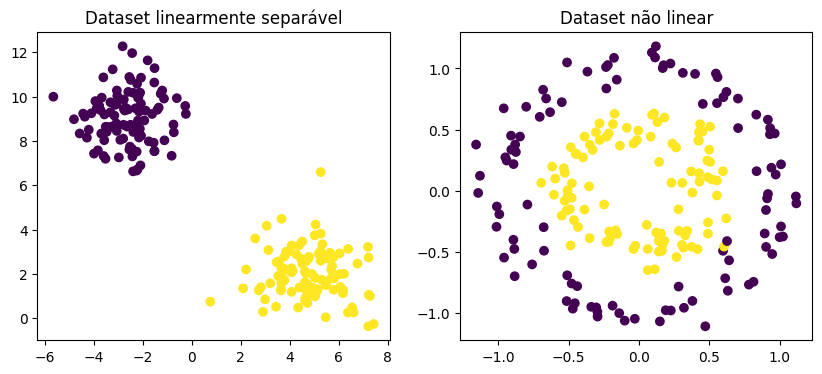

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].scatter(X_linear[:,0], X_linear[:,1], c=y_linear)
ax[0].set_title("Dataset linearmente separável")

ax[1].scatter(X_nonlinear[:,0], X_nonlinear[:,1], c=y_nonlinear)
ax[1].set_title("Dataset não linear")

plt.show()

In [7]:
def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(5,4))

    ax = plt.gca()

    xlim = (X[:, 0].min() - 1, X[:, 0].max() + 1)
    ylim = (X[:, 1].min() - 1, X[:, 1].max() + 1)

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(
        XX,
        YY,
        Z,
        levels=[0],
        colors='k'
    )

    ax.scatter(X[:,0], X[:,1], c=y)

    plt.title(title)
    plt.show()


In [8]:
def train_and_evaluate(X, y, kernel):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = svm.SVC(kernel=kernel)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    return model, acc

Accuracy (linear dataset): 1.0


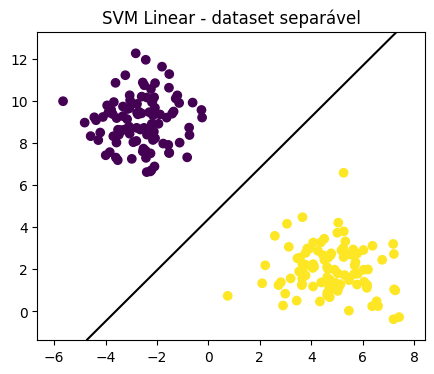

In [9]:
model_linear, acc_linear = train_and_evaluate(X_linear, y_linear, "linear")

print("Accuracy (linear dataset):", acc_linear)

plot_decision_boundary(
    model_linear,
    X_linear,
    y_linear,
    "SVM Linear - dataset separável"
)

Accuracy (non-linear dataset): 0.4666666666666667


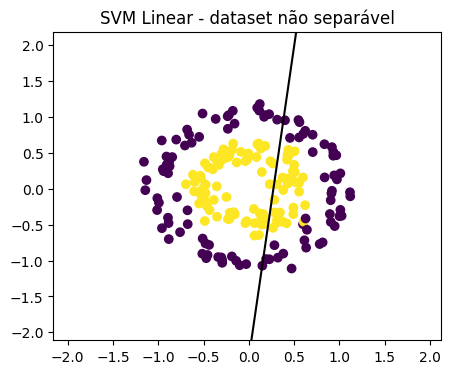

In [10]:
model_nonlinear, acc_nonlinear = train_and_evaluate(X_nonlinear, y_nonlinear, "linear")

print("Accuracy (non-linear dataset):", acc_nonlinear)

plot_decision_boundary(
    model_nonlinear,
    X_nonlinear,
    y_nonlinear,
    "SVM Linear - dataset não separável"
)

Accuracy (RBF kernel): 0.9833333333333333


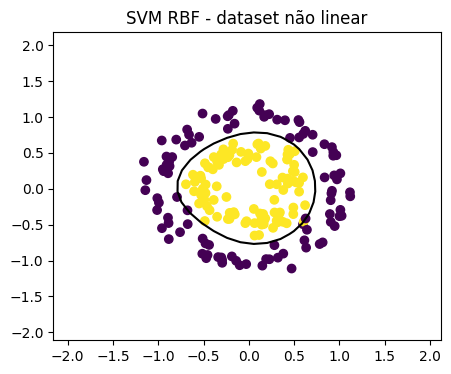

In [11]:
model_rbf, acc_rbf = train_and_evaluate(X_nonlinear, y_nonlinear, "rbf")

print("Accuracy (RBF kernel):", acc_rbf)

plot_decision_boundary(
    model_rbf,
    X_nonlinear,
    y_nonlinear,
    "SVM RBF - dataset não linear"
)